# P2 · Better Risk Estimates: Covariance Shrinkage

*Portfolio & Risk track*

P1 showed that optimisers amplify estimation error. This notebook fixes the risk side: a simple, widely used way to estimate the covariance matrix so that optimised portfolios hold up out-of-sample.

## 1. Motivation

A risk manager has one year of daily data on 43 stocks and needs their covariance matrix to build a minimum-risk portfolio. That matrix has 946 separate numbers to estimate from 252 days. Some estimated correlations will be too high and others too low, purely by chance. The optimiser can't tell which errors are which. It treats an unusually low estimated correlation as a real hedge and bets on it. Can we estimate risk in a way that the optimiser can't exploit?

## 2. Intuition

Imagine estimating the batting skill of 43 baseball players from their first 20 games. The player with the best record is probably good, but also probably lucky. A better guess pulls each player's record part of the way **towards the team average**. Extreme estimates are the ones most likely to contain luck, so they get pulled in the most.

**Shrinkage** applies the same idea to the covariance matrix. Mix the noisy **sample covariance** (lots of detail, lots of noise) with a simple, stable **target** (little detail, little noise), such as "all stocks have the average variance and are uncorrelated". The mix is less noisy than the sample estimate and more realistic than the target.

Ledoit and Wolf (2004) showed how to choose the mixing weight from the data itself, with no tuning needed.

## 3. The math

Let $S$ be the sample covariance matrix of $N$ assets estimated from $T$ days, and $F$ a structured target. The **shrinkage estimator** is
$$
\hat\Sigma = \delta\,F + (1-\delta)\,S, \qquad 0 \le \delta \le 1 .
$$
Here we use the simplest target, a scaled identity matrix: $F = \bar\sigma^2 I$, where $\bar\sigma^2 = \operatorname{trace}(S)/N$ is the average variance. In words: same variance for every asset, zero correlations.

**Choosing $\delta$.** Ledoit and Wolf choose $\delta$ to minimise the expected squared error $\mathbb{E}\,\|\hat\Sigma - \Sigma\|^2$ between the estimate and the true (unknown) matrix. The optimal $\delta$ is roughly
$$
\delta^* \approx \frac{\text{noise in } S}{\text{noise in } S + \text{distance between } S \text{ and } F}.
$$
It is large when $S$ is noisy (few observations $T$ relative to assets $N$), and small when the data clearly disagrees with the target. Both quantities can be estimated from the data. `sklearn` does this for us.

**Why it helps the optimiser.** Sampling noise spreads the eigenvalues of $S$: the smallest ones are too small. The optimiser loves directions with tiny estimated variance (the GMV formula contains $\Sigma^{-1}$, which blows those directions up). Shrinkage pulls every eigenvalue towards $\bar\sigma^2$, which removes the fake low-risk directions.

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

stocks = meta.loc[meta.asset_type == "stock", "ticker"].tolist()
returns = prices[stocks].pct_change().dropna()
print(f"N = {len(stocks)} stocks -> {len(stocks) * (len(stocks) + 1) // 2} distinct covariance entries")

N = 43 stocks -> 946 distinct covariance entries


### 4.2 Sample vs. shrunk covariance on one year of data

In [2]:
window = returns.loc["2019"]                    # one year: T = 252 days

S = window.cov().values * 252                  # sample covariance (annualised)
lw = LedoitWolf().fit(window.values)           # estimates delta* and the shrunk matrix
Sigma_lw = lw.covariance_ * 252
print(f"Ledoit-Wolf shrinkage intensity delta* = {lw.shrinkage_:.2f}")

# Check the formula by hand: delta * F + (1 - delta) * S, with F = average variance x identity
S0 = window.cov(ddof=0).values * 252           # sklearn divides by T, not T - 1
F = np.trace(S0) / len(S0) * np.eye(len(S0))
by_hand = lw.shrinkage_ * F + (1 - lw.shrinkage_) * S0
print(f"Max difference vs. sklearn: {np.abs(by_hand - Sigma_lw).max():.1e}")

Ledoit-Wolf shrinkage intensity delta* = 0.05
Max difference vs. sklearn: 1.4e-17


The hand-built formula matches sklearn exactly. Next, the eigenvalues: each one is the variance of the portfolio along one direction.

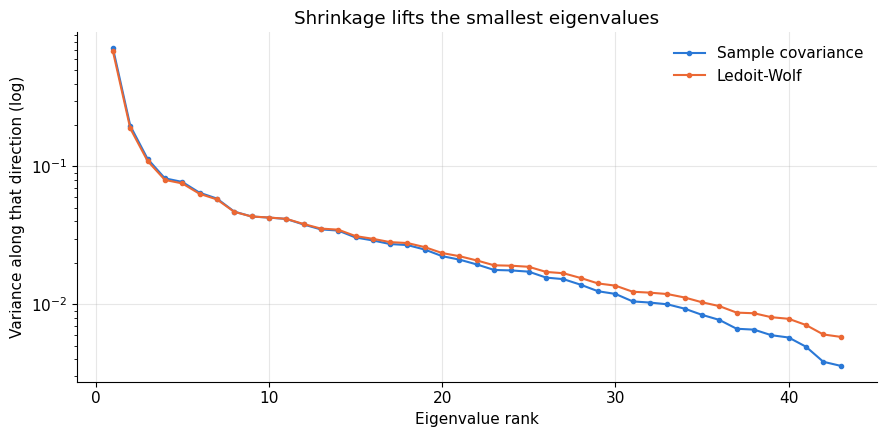

Smallest eigenvalue: sample 0.0036, Ledoit-Wolf 0.0058


In [3]:
eig_sample = np.sort(np.linalg.eigvalsh(S))[::-1]
eig_lw = np.sort(np.linalg.eigvalsh(Sigma_lw))[::-1]

fig, ax = plt.subplots()
ax.plot(range(1, len(S) + 1), eig_sample, marker="o", markersize=3, label="Sample covariance")
ax.plot(range(1, len(S) + 1), eig_lw, marker="o", markersize=3, label="Ledoit-Wolf")
ax.set_yscale("log")
ax.set_xlabel("Eigenvalue rank")
ax.set_ylabel("Variance along that direction (log)")
ax.set_title("Shrinkage lifts the smallest eigenvalues")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
print(f"Smallest eigenvalue: sample {eig_sample[-1]:.4f}, Ledoit-Wolf {eig_lw[-1]:.4f}")

The largest eigenvalues hardly change. The largest one is the market direction, where everything moves together, and it is estimated well. The smallest eigenvalues are lifted by more than half (0.0036 → 0.0058). These are the "fake hedges": combinations of stocks that look almost riskless in this particular year only because of sampling noise. The optimiser would have leaned on exactly these directions.

### 4.3 Out-of-sample test: minimum-variance portfolios

The real test. At the end of every month we estimate the covariance from the past 252 days, build the GMV portfolio (formula from P1), and hold it for the next month. We do this with three estimates: the sample covariance, Ledoit–Wolf, and equal weights as a baseline. The goal of GMV is low risk, so we judge each one by its **realised out-of-sample volatility**.

In [4]:
def gmv_weights(Sigma):
    x = np.linalg.solve(Sigma, np.ones(len(Sigma)))   # Sigma^{-1} 1
    return x / x.sum()

month_ends = returns.groupby(returns.index.to_period("M")).tail(1).index
oos = {"Sample GMV": [], "Ledoit-Wolf GMV": [], "Equal weight": []}
max_weight = {"Sample GMV": [], "Ledoit-Wolf GMV": []}

for i, date in enumerate(month_ends[:-1]):
    past = returns.loc[:date].tail(252)                     # estimation window: last 252 days
    if len(past) < 252:
        continue
    nxt = returns.loc[date:month_ends[i + 1]].iloc[1:]      # the following month (out of sample)
    w_s = gmv_weights(past.cov().values)
    w_lw = gmv_weights(LedoitWolf().fit(past.values).covariance_)
    w_eq = np.full(len(stocks), 1 / len(stocks))
    for name, w in [("Sample GMV", w_s), ("Ledoit-Wolf GMV", w_lw), ("Equal weight", w_eq)]:
        oos[name].append(nxt.values @ w)                    # daily returns of the held portfolio
    max_weight["Sample GMV"].append(np.abs(w_s).max())
    max_weight["Ledoit-Wolf GMV"].append(np.abs(w_lw).max())

oos = {k: np.concatenate(v) for k, v in oos.items()}
result = pd.DataFrame({
    "Realised volatility": {k: v.std() * np.sqrt(252) for k, v in oos.items()},
    "Avg max |weight|": {k: np.mean(v) for k, v in max_weight.items()},
})
result.map(lambda x: f"{x:.1%}" if pd.notna(x) else "-")

,Realised volatility,Avg max |weight|
Sample GMV,13.4%,25.7%
Ledoit-Wolf GMV,12.9%,18.6%
Equal weight,15.8%,-


- **Both GMV portfolios beat equal weight on risk** (about 13% vs 16% volatility), as they are designed to.
- **Ledoit–Wolf is less risky out-of-sample than the sample estimate** (12.9% vs 13.4%). It also holds much less extreme positions: on average its largest position is about 19% of capital, against 26% for the sample version.

The gain looks modest because 252 days is a fair amount of data for 43 stocks, so $\delta^*$ is small. With more assets or less data, the sample covariance gets worse quickly and the advantage of shrinkage grows.

### 4.4 How much shrinkage over time?

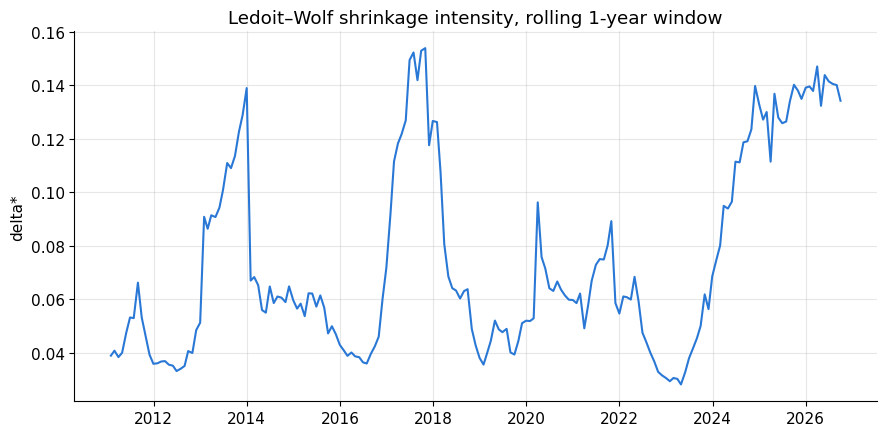

In [5]:
deltas = pd.Series({d: LedoitWolf().fit(returns.loc[:d].tail(252).values).shrinkage_
                    for d in month_ends[12:]})
fig, ax = plt.subplots()
ax.plot(deltas.index, deltas, color=COLORS[0])
ax.set_ylabel("delta*")
ax.set_title("Ledoit–Wolf shrinkage intensity, rolling 1-year window")
plt.tight_layout()
plt.show()

$\delta^*$ moves between about 0.03 and 0.15. It is highest in calm, low-correlation years (2017, 2025–26), when the data is close to the "uncorrelated" target and noise dominates. It is lowest when stocks move strongly together (2012, 2023), because then the data clearly disagrees with the target. The estimator adapts automatically, which is part of its appeal.

## 5. Takeaways and where it breaks

- **Shrinkage is close to a free lunch.** It needs one extra line of code and no tuning, and it makes optimised portfolios less extreme and less risky out-of-sample.
- **It fixes the risk side only.** Expected returns are still the bigger problem (P1). The **Black–Litterman** model applies the same shrinkage idea to $\mu$: it starts from returns implied by market weights and moves them only as far as the investor's views justify.
- **The target matters.** The identity target ignores the fact that all stocks share market risk. A "constant correlation" target or a one-factor target (P4) usually works better for stocks.
- **Where it breaks:** shrinkage reduces noise but can't predict change. If correlations jump in a crisis (notebook 3), last year's covariance, shrunk or not, will understate risk.
- **N vs T:** with more assets than days ($N > T$) the sample covariance can't even be inverted. Shrinkage still works, which is why it is standard for large universes.

**What you could build:** a risk-model module for the club that produces a shrunk covariance matrix each month, so every portfolio project uses the same, robust risk estimate.